# Wheat Disease Classification — Final Submission Notebook

**Course:** Deep Learning, Spring 2026 — University of Jordan
**Instructor:** Dr. Tamam AlSarhan
**Competition:** Beyond Visible Spectrum: AI for Agriculture 2026 (ICPR 2026)
**Task:** Classify wheat-field image patches into `Health`, `Rust`, or `Other`

---

## What this notebook does

A controlled **three-way ablation** that progressively adds modalities:

| Model | Input | Channels | Story |
|-------|-------|----------|-------|
| **A** | RGB only | 3 | Baseline using only visible spectrum |
| **B** | RGB + MS | 8 | Adds 5 multispectral bands (Red Edge + NIR) |
| **C** | RGB + MS + HS | 24 | Adds 125 hyperspectral bands via a learned 1D spectral encoder |

All three models are trained identically (same backbone, optimizer, augmentation, seed, 5-fold CV) so any difference in performance is attributable to the input modality.

## Pipeline

1. Set up environment and load the dataset
2. **EDA** — visualize class samples and hyperspectral signatures (motivates the multimodal approach)
3. Build the training dataframe and dataset class supporting all three modalities
4. Define the model with the learned HS spectral encoder
5. 5-fold stratified cross-validation training
6. Evaluation: per-class metrics, confusion matrix, per-fold chart
7. Generate Kaggle submission (5-fold soft-vote ensemble)

**Runtime on Kaggle T4 GPU:** ~35 minutes total.

## 1. Environment Setup

Pinned versions for reproducibility. We deliberately use `torchvision` for transforms instead of `albumentations` because the Kaggle environment has an `albumentations`-vs-`numpy` compatibility issue at the time of writing.

In [1]:
!pip install -q timm==1.0.7 rasterio==1.3.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 72.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.13.0 requires rasterio>=1.4, but you have rasterio 1.3.10 which is incompatible.


In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import rasterio

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
warnings.filterwarnings('ignore', category=UserWarning)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'none')

Device: cuda
GPU: Tesla T4


## 2. Reproducibility

Fixed seeds for Python's `random`, NumPy, PyTorch (CPU + GPU), and cuDNN set to deterministic mode.

In [3]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Seed set to {SEED}')

Seed set to 42


## 3. Configuration

All paths and hyperparameters in one place. If the data path differs on your environment, only this cell needs editing.

In [4]:
# === PATHS ===
DATA_ROOT = Path('/kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared')
OUTPUT_DIR = Path('/kaggle/working')
FIG_DIR = OUTPUT_DIR / 'figures'
CKPT_DIR = OUTPUT_DIR / 'checkpoints'
FIG_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR.mkdir(exist_ok=True, parents=True)

# === CLASS MAPPING ===
CLASS_TO_IDX = {'Health': 0, 'Rust': 1, 'Other': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
CLASS_NAMES = ['Health', 'Rust', 'Other']
NUM_CLASSES = 3

# === MODEL / TRAINING ===
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
N_FOLDS = 5
HS_BANDS = 125         # number of hyperspectral bands (truncate if file has more)
HS_ENCODED_CH = 16     # output channels of the learned HS spectral encoder

# === IMAGENET STATS (for the pretrained RGB channels) ===
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Sanity check
assert DATA_ROOT.exists(), f'DATA_ROOT does not exist: {DATA_ROOT}\nCheck the Input panel and adjust the path.'
print(f'Data root OK: {DATA_ROOT}')
print(f'Train RGB files: {len(list((DATA_ROOT / "train" / "RGB").iterdir()))}')
print(f'Val RGB files:   {len(list((DATA_ROOT / "val" / "RGB").iterdir()))}')

Data root OK: /kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared
Train RGB files: 600
Val RGB files:   300


## 4. Build Training Dataframe

Filenames look like `Health_hyper_42.png`. We parse the class from the prefix and store paths to all three modality files for each sample. Files are matched by their stem ID, not by alphabetical order, so RGB ↔ MS ↔ HS pairing is correct.

In [5]:
def build_train_df():
    records = []
    rgb_dir = DATA_ROOT / 'train' / 'RGB'
    for fp in sorted(rgb_dir.iterdir()):
        cls_name = fp.stem.split('_')[0]
        sample_id = fp.stem.split('_')[-1]
        records.append({
            'sample_id': f'{cls_name}_{sample_id}',
            'rgb_path': str(fp),
            'ms_path':  str(DATA_ROOT / 'train' / 'MS' / f'{fp.stem}.tif'),
            'hs_path':  str(DATA_ROOT / 'train' / 'HS' / f'{fp.stem}.tif'),
            'label': CLASS_TO_IDX[cls_name],
            'class_name': cls_name,
        })
    return pd.DataFrame(records)

train_df = build_train_df()
print(f'Total training samples: {len(train_df)}')
print('Class balance:')
print(train_df['class_name'].value_counts())
train_df.head()

Total training samples: 600
Class balance:
class_name
Health    200
Other     200
Rust      200
Name: count, dtype: int64


,sample_id,rgb_path,ms_path,hs_path,label,class_name
0,Health_1,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
1,Health_10,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
2,Health_100,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
3,Health_101,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
4,Health_102,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health


## 5. EDA — One sample per class, per modality

This figure shows that:
- At 64×64, RGB visually struggles to distinguish Health from Rust
- MS NIR clearly separates vegetation from non-vegetation
- HS is at half the spatial resolution (32×32) but encodes 125 bands of spectral information

Health: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)
Rust: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)
Other: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)


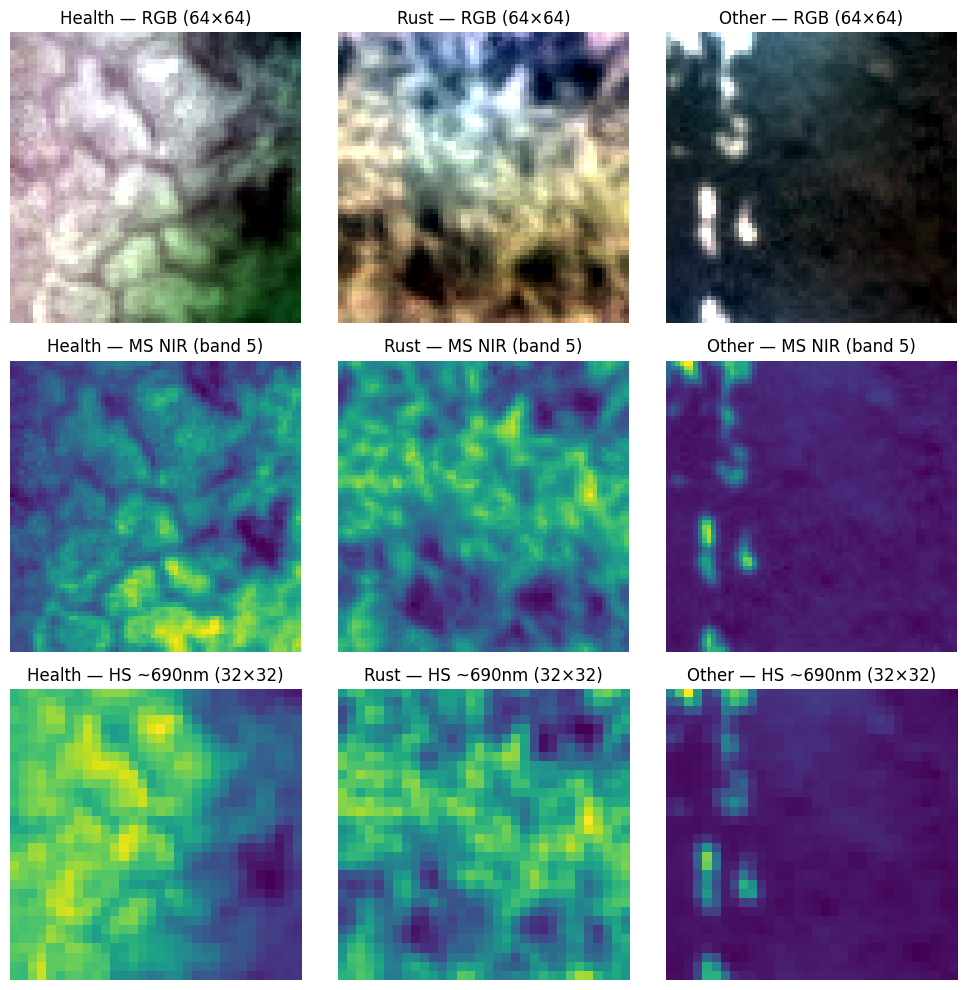

Saved: /kaggle/working/figures/fig1_samples_per_class.png


In [6]:
def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'))

def load_tif(path):
    with rasterio.open(path) as src:
        return src.read()

samples = {}
for cls in CLASS_NAMES:
    row = train_df[train_df['class_name'] == cls].iloc[0]
    samples[cls] = {
        'rgb': load_rgb(row['rgb_path']),
        'ms':  load_tif(row['ms_path']),
        'hs':  load_tif(row['hs_path']),
    }
    print(f'{cls}: RGB {samples[cls]["rgb"].shape}, MS {samples[cls]["ms"].shape}, HS {samples[cls]["hs"].shape}')

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for col, cls in enumerate(CLASS_NAMES):
    s = samples[cls]
    axes[0, col].imshow(s['rgb'])
    axes[0, col].set_title(f'{cls} — RGB (64×64)')
    axes[1, col].imshow(s['ms'][4], cmap='viridis')
    axes[1, col].set_title(f'{cls} — MS NIR (band 5)')
    axes[2, col].imshow(s['hs'][60], cmap='viridis')
    axes[2, col].set_title(f'{cls} — HS ~690nm (32×32)')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_samples_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig1_samples_per_class.png')

## 6. EDA — Mean hyperspectral signature per class

**The diagnostic plot for this entire project.** For each class, we average all 200 training samples spatially within each of the 125 spectral bands, producing one mean reflectance value per band per class.

The shaded red-edge region (680–750 nm) is where Health and Rust diverge most strongly — and where RGB has no information. This observation motivates the three-way ablation: each successive modality samples this region more densely.

Some HS files in the dataset have 126 bands instead of 125 (sensor format quirk); we truncate to 125.

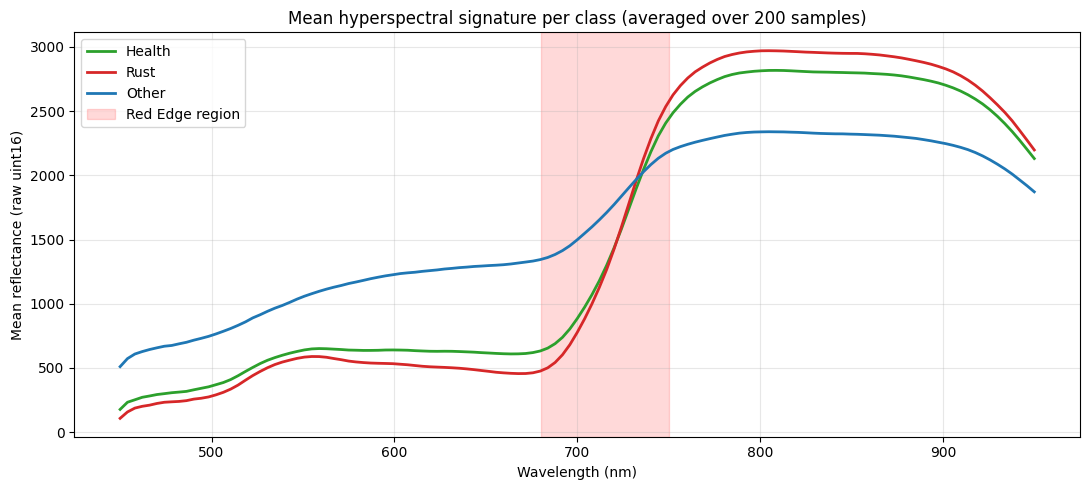

Saved: /kaggle/working/figures/fig2_hs_signatures.png

Top 5 most discriminative bands for Rust vs Health:
  band  56  (676 nm)  diff = -157.5
  band  85  (793 nm)  diff = +157.0
  band  81  (777 nm)  diff = +156.7
  band  57  (680 nm)  diff = -156.6
  band  82  (781 nm)  diff = +156.5


In [7]:
wavelengths = np.linspace(450, 950, HS_BANDS)

mean_signatures = {}
for cls in CLASS_NAMES:
    files = train_df[train_df['class_name'] == cls]['hs_path'].tolist()
    accum = np.zeros(HS_BANDS, dtype=np.float64)
    kept = 0
    for f in tqdm(files, desc=cls, leave=False):
        cube = load_tif(f).astype(np.float32)
        if cube.shape[0] < HS_BANDS:
            continue
        cube = cube[:HS_BANDS]
        accum += cube.mean(axis=(1, 2))
        kept += 1
    mean_signatures[cls] = accum / kept

fig, ax = plt.subplots(figsize=(11, 5))
colors = {'Health': '#2ca02c', 'Rust': '#d62728', 'Other': '#1f77b4'}
for cls in CLASS_NAMES:
    ax.plot(wavelengths, mean_signatures[cls], label=cls, linewidth=2, color=colors[cls])
ax.axvspan(680, 750, alpha=0.15, color='red', label='Red Edge region')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Mean reflectance (raw uint16)')
ax.set_title('Mean hyperspectral signature per class (averaged over 200 samples)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_hs_signatures.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig2_hs_signatures.png')

# Identify the most discriminative bands for Rust vs Health
diff_rust = mean_signatures['Rust'] - mean_signatures['Health']
top5 = np.argsort(np.abs(diff_rust))[-5:][::-1]
print('\nTop 5 most discriminative bands for Rust vs Health:')
for idx in top5:
    print(f'  band {idx:3d}  ({wavelengths[idx]:.0f} nm)  diff = {diff_rust[idx]:+.1f}')

## 7. Compute per-band normalization statistics

The HS and MS modalities have no pretrained statistics (unlike RGB which uses ImageNet stats). We compute per-band mean and standard deviation on the training set once, and use these for z-score normalization throughout.

In [8]:
# === HS statistics ===
print('Computing HS per-band mean/std on training set...')
hs_sums = np.zeros(HS_BANDS, dtype=np.float64)
hs_sq_sums = np.zeros(HS_BANDS, dtype=np.float64)
hs_count = 0
for p in tqdm(train_df['hs_path'].tolist()):
    with rasterio.open(p) as src:
        hs = src.read().astype(np.float32)
    hs = hs[:HS_BANDS]
    hs_sums += hs.sum(axis=(1, 2))
    hs_sq_sums += (hs ** 2).sum(axis=(1, 2))
    hs_count += hs.shape[1] * hs.shape[2]
HS_MEAN = hs_sums / hs_count
HS_STD  = np.sqrt(np.maximum(hs_sq_sums / hs_count - HS_MEAN ** 2, 0))
print(f'HS_MEAN range: [{HS_MEAN.min():.1f}, {HS_MEAN.max():.1f}]')
print(f'HS_STD range:  [{HS_STD.min():.1f}, {HS_STD.max():.1f}]')

# === MS statistics ===
print('\nComputing MS per-band mean/std on training set...')
ms_sums = np.zeros(5, dtype=np.float64)
ms_sq_sums = np.zeros(5, dtype=np.float64)
ms_count = 0
for p in tqdm(train_df['ms_path'].tolist()):
    with rasterio.open(p) as src:
        ms = src.read().astype(np.float32)
    ms_sums += ms.sum(axis=(1, 2))
    ms_sq_sums += (ms ** 2).sum(axis=(1, 2))
    ms_count += ms.shape[1] * ms.shape[2]
MS_MEAN = ms_sums / ms_count
MS_STD  = np.sqrt(np.maximum(ms_sq_sums / ms_count - MS_MEAN ** 2, 0))
print(f'MS_MEAN: {MS_MEAN.round(1)}')
print(f'MS_STD:  {MS_STD.round(1)}')

Computing HS per-band mean/std on training set...


100%|██████████| 600/600 [00:04<00:00, 123.08it/s]


HS_MEAN range: [264.6, 2708.8]
HS_STD range:  [330.0, 1119.3]

Computing MS per-band mean/std on training set...


100%|██████████| 600/600 [00:06<00:00, 89.12it/s]

MS_MEAN: [ 412.8  760.9  795.4 2184.5 2693.5]
MS_STD:  [ 377.8  469.2  665.5  858.2 1127.9]


## 8. Tri-modal Dataset Class

The dataset returns a dictionary containing:
- `rgb_ms`: an (8, 224, 224) tensor with RGB (ImageNet-normalized) stacked with MS (z-score normalized, upsampled from 64×64)
- `hs`: a (125, 32, 32) tensor with HS (z-score normalized, kept at native resolution — the model upsamples after the spectral encoder)

**Design choices:**
- All inputs are resized to 224×224 (matching ImageNet pretraining of ResNet50)
- ImageNet normalization for RGB; per-band z-score for MS and HS (no pretraining available)
- Geometric augmentations (flip, 90° rotation) are applied to all modalities simultaneously to preserve co-registration
- Light color jitter only on RGB (color is part of the disease signal — heavy jitter would destroy it)

In [9]:
class WheatTriModalDataset(Dataset):
    """Loads RGB + MS + HS for the wheat disease classification task.

    Returns:
        sample (dict): {'rgb_ms': (8, 224, 224), 'hs': (125, 32, 32)}
        label  (long): class index in {0, 1, 2}
    """

    def __init__(self, df, train: bool):
        self.df = df.reset_index(drop=True)
        self.train = train
        self.rgb_aug = T.ColorJitter(brightness=0.1, contrast=0.1,
                                     saturation=0.05, hue=0.02) if train else None

    def __len__(self):
        return len(self.df)

    def _load_rgb(self, path):
        """PNG → (3, 224, 224) tensor with ImageNet normalization."""
        img = Image.open(path).convert('RGB')
        if self.train and self.rgb_aug is not None:
            img = self.rgb_aug(img)
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr = np.array(img).astype(np.float32) / 255.0
        arr = (arr - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
        return torch.from_numpy(arr.transpose(2, 0, 1)).float()

    def _load_ms(self, path):
        """TIFF → (5, 224, 224) tensor, z-score normalized."""
        with rasterio.open(path) as src:
            ms = src.read().astype(np.float32)
        ms = (ms - MS_MEAN[:, None, None]) / (MS_STD[:, None, None] + 1e-6)
        ms_t = torch.from_numpy(ms).unsqueeze(0)
        ms_t = F.interpolate(ms_t, size=(IMG_SIZE, IMG_SIZE),
                             mode='bilinear', align_corners=False)
        return ms_t.squeeze(0).float()

    def _load_hs(self, path):
        """TIFF → (125, 32, 32) tensor, z-score normalized."""
        with rasterio.open(path) as src:
            hs = src.read().astype(np.float32)
        hs = hs[:HS_BANDS]
        hs = (hs - HS_MEAN[:, None, None]) / (HS_STD[:, None, None] + 1e-6)
        return torch.from_numpy(hs).float()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rgb = self._load_rgb(row['rgb_path'])
        ms  = self._load_ms(row['ms_path'])
        hs  = self._load_hs(row['hs_path'])

        rgb_ms = torch.cat([rgb, ms], dim=0)

        # Geometric augmentation applied to all modalities (preserves co-registration)
        if self.train:
            if random.random() < 0.5:
                rgb_ms = torch.flip(rgb_ms, dims=[2])
                hs = torch.flip(hs, dims=[2])
            if random.random() < 0.5:
                rgb_ms = torch.flip(rgb_ms, dims=[1])
                hs = torch.flip(hs, dims=[1])
            k = random.randint(0, 3)
            if k > 0:
                rgb_ms = torch.rot90(rgb_ms, k=k, dims=[1, 2])
                hs = torch.rot90(hs, k=k, dims=[1, 2])

        label = torch.tensor(row['label'], dtype=torch.long)
        return {'rgb_ms': rgb_ms, 'hs': hs}, label


# Sanity check
_ds = WheatTriModalDataset(train_df.head(4), train=False)
sample, _y = _ds[0]
print(f"rgb_ms tensor: shape {tuple(sample['rgb_ms'].shape)}, range [{sample['rgb_ms'].min():.2f}, {sample['rgb_ms'].max():.2f}]")
print(f"hs tensor:     shape {tuple(sample['hs'].shape)}, range [{sample['hs'].min():.2f}, {sample['hs'].max():.2f}]")
print(f"Label: {_y.item()} ({IDX_TO_CLASS[_y.item()]})")

rgb_ms tensor: shape (8, 224, 224), range [-2.12, 2.64]
hs tensor:     shape (125, 32, 32), range [-0.49, 2.19]
Label: 0 (Health)


## 9. Model — Tri-Modal ResNet50 with Learned HS Spectral Encoder

**The key novelty.** The 125 HS bands cannot be fed directly to ImageNet-pretrained convolutional filters that expect 3 channels. Rather than discarding bands manually or using PCA, we learn a compact 16-channel summary using **1×1 convolutions along the spectral axis**.

### `HSSpectralEncoder`
- Treats each spatial pixel as a length-125 spectral sequence
- Applies `Conv1d(125 → 64 → 16)` along the spectral dimension
- Bilinearly upsamples the resulting (16, 32, 32) tensor to (16, 224, 224)
- Adds only ~10K parameters (negligible vs ResNet50's 25M, so any gain is from the bands themselves)

### `TriModalModel`
- Concatenates RGB+MS (8 channels, 224×224) with the encoded HS (16 channels, 224×224)
- Feeds the 24-channel input into ResNet50 with `in_chans=24`
- `timm` averages the pretrained 3-channel first-layer weights across the additional channels, preserving the ImageNet prior on the RGB channels

In [10]:
class HSSpectralEncoder(nn.Module):
    """Compresses 125 HS bands into 16 channels using 1D conv along the spectral axis.

    Operates independently at each spatial pixel: treats the 32x32 = 1024 pixels
    as a batch of length-125 spectral sequences. Then upsamples to 224x224.
    """

    def __init__(self, in_bands=HS_BANDS, hidden=64, out_ch=HS_ENCODED_CH):
        super().__init__()
        self.spectral = nn.Sequential(
            nn.Conv1d(in_bands, hidden, kernel_size=1),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Conv1d(hidden, out_ch, kernel_size=1),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        # x: (B, 125, H, W)
        B, C, H, W = x.shape
        x = x.reshape(B, C, H * W)
        x = self.spectral(x)
        x = x.reshape(B, -1, H, W)
        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE),
                          mode='bilinear', align_corners=False)
        return x


class TriModalModel(nn.Module):
    """RGB+MS (8 ch, 224x224) + HS (encoded to 16 ch, 224x224) → ResNet50."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.hs_encoder = HSSpectralEncoder(in_bands=HS_BANDS,
                                            hidden=64,
                                            out_ch=HS_ENCODED_CH)
        self.backbone = timm.create_model(
            'resnet50',
            pretrained=True,
            num_classes=num_classes,
            in_chans=8 + HS_ENCODED_CH,   # 24 channels
        )

    def forward(self, rgb_ms, hs):
        hs_feat = self.hs_encoder(hs)
        x = torch.cat([rgb_ms, hs_feat], dim=1)
        return self.backbone(x)


def build_model():
    return TriModalModel(num_classes=NUM_CLASSES)


# Quick test
_m = build_model().to(DEVICE)
_rgbms = torch.randn(2, 8, IMG_SIZE, IMG_SIZE).to(DEVICE)
_hs = torch.randn(2, HS_BANDS, 32, 32).to(DEVICE)
with torch.no_grad():
    _out = _m(_rgbms, _hs)
print(f'Model output shape: {tuple(_out.shape)} (should be [2, 3])')
n_params = sum(p.numel() for p in _m.parameters())
print(f'Trainable parameters: {n_params:,}')
del _m, _rgbms, _hs, _out
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model output shape: (2, 3) (should be [2, 3])
Trainable parameters: 23,589,299


## 10. Training and Validation Functions

Standard PyTorch training and evaluation. We track both accuracy and macro-F1; the best checkpoint per fold is selected by macro-F1 on the held-out validation set.

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch, y in loader:
        rgb_ms = batch['rgb_ms'].to(DEVICE, non_blocking=True)
        hs = batch['hs'].to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(rgb_ms, hs)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    for batch, y in loader:
        rgb_ms = batch['rgb_ms'].to(DEVICE, non_blocking=True)
        hs = batch['hs'].to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(rgb_ms, hs)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_targets)).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    return total_loss / len(all_targets), acc, macro_f1, all_preds, all_targets

## 11. 5-Fold Stratified Cross-Validation Training

We train 5 separate models, each on a different 480/120 train/validation split. The best checkpoint per fold (by macro-F1) is saved for later ensembling.

**Hyperparameters:**
- 25 epochs, AdamW optimizer (lr=1e-4, weight decay=1e-4)
- Cosine annealing LR schedule (decays smoothly to 0)
- Cross-entropy loss (no focal/weighted loss — classes are perfectly balanced)
- Batch size 32

**Runtime:** ~35 minutes on Kaggle T4 GPU.

In [12]:
import time
import rasterio
from PIL import Image

# Time how long it takes to load one sample of each modality
row = train_df.iloc[0]

t0 = time.time()
img = Image.open(row['rgb_path']).convert('RGB')
print(f'RGB load:  {(time.time()-t0)*1000:.0f} ms')

t0 = time.time()
with rasterio.open(row['ms_path']) as src: ms = src.read()
print(f'MS load:   {(time.time()-t0)*1000:.0f} ms')

t0 = time.time()
with rasterio.open(row['hs_path']) as src: hs = src.read()
print(f'HS load:   {(time.time()-t0)*1000:.0f} ms')

print(f'\nEstimated time per epoch (~600 samples, batch=32):')
total_ms = ((time.time()-t0)*1000 + 5 + 10) * 600
print(f'  ~{total_ms/1000:.0f} seconds = ~{total_ms/60000:.1f} minutes')

RGB load:  2 ms
MS load:   5 ms
HS load:   9 ms

Estimated time per epoch (~600 samples, batch=32):
  ~15 seconds = ~0.2 minutes


In [13]:
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,utilization.gpu',
                        '--format=csv,noheader'], capture_output=True, text=True)
print(result.stdout)

Tesla T4, 15360 MiB, 8 %
Tesla T4, 15360 MiB, 0 %



In [14]:
# Workaround for a torch._utils auto-loading issue in some Kaggle environments
import importlib
importlib.import_module('torch._utils')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
all_fold_preds = []       # OOF predictions across all 5 folds
all_fold_targets = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df['label'])):
    print(f'\n{"="*60}\nFOLD {fold + 1}/{N_FOLDS}\n{"="*60}')
    set_seed(SEED + fold)

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    va_df = train_df.iloc[va_idx].reset_index(drop=True)

    tr_ds = WheatTriModalDataset(tr_df, train=True)
    va_ds = WheatTriModalDataset(va_df, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=4, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=4, pin_memory=True)

    model = build_model().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_epoch = 0.0, 0

    for epoch in range(EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, _, _ = validate(model, va_loader, criterion)
        scheduler.step()

        flag = ' ★' if va_f1 > best_f1 else ''
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
              f'tr_loss {tr_loss:.3f} tr_acc {tr_acc:.3f} | '
              f'va_loss {va_loss:.3f} va_acc {va_acc:.3f} va_f1 {va_f1:.3f}{flag}')

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_epoch = epoch
            torch.save(model.state_dict(), CKPT_DIR / f'fold{fold}_best.pt')

    # Reload best checkpoint and record OOF predictions for this fold
    model.load_state_dict(torch.load(CKPT_DIR / f'fold{fold}_best.pt'))
    _, va_acc, va_f1, preds, targets = validate(model, va_loader, criterion)
    print(f'\n>>> Fold {fold+1} BEST: epoch {best_epoch+1}, '
          f'val_acc={va_acc:.4f}, val_f1={va_f1:.4f}')
    print(classification_report(targets, preds, target_names=CLASS_NAMES, digits=3))

    fold_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch + 1,
        'val_acc': va_acc,
        'val_f1': va_f1,
    })
    all_fold_preds.extend(preds)
    all_fold_targets.extend(targets)

    del model
    torch.cuda.empty_cache()

results_df = pd.DataFrame(fold_results)
print('\n' + '='*60)
print('5-FOLD CROSS-VALIDATION SUMMARY')
print('='*60)
print(results_df.to_string(index=False))
print(f'\nMean accuracy: {results_df.val_acc.mean():.4f} ± {results_df.val_acc.std():.4f}')
print(f'Mean macro-F1: {results_df.val_f1.mean():.4f} ± {results_df.val_f1.std():.4f}')

results_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)
print(f'\nSaved: cv_results.csv')


FOLD 1/5


Epoch 01/25 | tr_loss 1.095 tr_acc 0.358 | va_loss 1.098 va_acc 0.317 va_f1 0.272 ★
Epoch 02/25 | tr_loss 1.069 tr_acc 0.525 | va_loss 1.085 va_acc 0.558 va_f1 0.559 ★
Epoch 03/25 | tr_loss 1.034 tr_acc 0.588 | va_loss 1.035 va_acc 0.575 va_f1 0.573 ★
Epoch 04/25 | tr_loss 1.001 tr_acc 0.600 | va_loss 0.967 va_acc 0.617 va_f1 0.575 ★
Epoch 05/25 | tr_loss 0.959 tr_acc 0.610 | va_loss 0.904 va_acc 0.667 va_f1 0.617 ★
Epoch 06/25 | tr_loss 0.920 tr_acc 0.590 | va_loss 0.860 va_acc 0.658 va_f1 0.621 ★
Epoch 07/25 | tr_loss 0.872 tr_acc 0.596 | va_loss 0.823 va_acc 0.608 va_f1 0.529
Epoch 08/25 | tr_loss 0.854 tr_acc 0.613 | va_loss 0.804 va_acc 0.633 va_f1 0.562
Epoch 09/25 | tr_loss 0.836 tr_acc 0.600 | va_loss 0.777 va_acc 0.650 va_f1 0.598
Epoch 10/25 | tr_loss 0.821 tr_acc 0.629 | va_loss 0.766 va_acc 0.667 va_f1 0.604
Epoch 11/25 | tr_loss 0.788 tr_acc 0.623 | va_loss 0.760 va_acc 0.667 va_f1 0.613
Epoch 12/25 | tr_loss 0.783 tr_acc 0.633 | va_loss 0.753 va_acc 0.667 va_f1 0.604
Epoc

## 12. Out-of-Fold Confusion Matrix and Per-Class Report

Aggregates predictions across all 5 folds (so each training sample is predicted exactly once by a model that didn't see it during training). This gives the most reliable view of per-class performance.

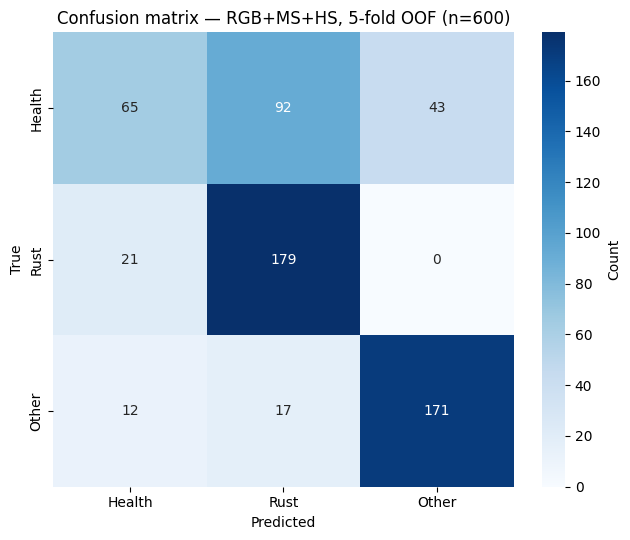

Saved: /kaggle/working/figures/fig3_confusion_matrix.png

Out-of-fold classification report:
              precision    recall  f1-score   support

      Health      0.663     0.325     0.436       200
        Rust      0.622     0.895     0.734       200
       Other      0.799     0.855     0.826       200

    accuracy                          0.692       600
   macro avg      0.695     0.692     0.665       600
weighted avg      0.695     0.692     0.665       600



In [19]:
cm = confusion_matrix(all_fold_targets, all_fold_preds, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — RGB+MS+HS, 5-fold OOF (n={len(all_fold_targets)})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig3_confusion_matrix.png')

print('\nOut-of-fold classification report:')
print(classification_report(all_fold_targets, all_fold_preds, target_names=CLASS_NAMES, digits=3))

## 13. Generate Kaggle Submission (5-Fold Soft-Vote Ensemble)

Predicts on the 300 validation samples using all 5 fold models and averages their softmax probabilities. On small datasets this typically improves accuracy by 1–2 percentage points over any single fold.

In [20]:
# Build val dataframe with all three modality paths
val_rgb_dir = DATA_ROOT / 'val' / 'RGB'
val_records = [{'rgb_path': str(fp),
                'ms_path':  str(DATA_ROOT / 'val' / 'MS' / f'{fp.stem}.tif'),
                'hs_path':  str(DATA_ROOT / 'val' / 'HS' / f'{fp.stem}.tif'),
                'filename': fp.name}
               for fp in sorted(val_rgb_dir.iterdir())]
val_df = pd.DataFrame(val_records)
val_df['label'] = 0   # placeholder, not used at inference
print(f'Validation samples: {len(val_df)}')

val_ds = WheatTriModalDataset(val_df, train=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# Soft-vote ensemble across the 5 fold models
all_fold_probs = []
for fold in range(N_FOLDS):
    model = build_model().to(DEVICE)
    model.load_state_dict(torch.load(CKPT_DIR / f'fold{fold}_best.pt'))
    model.eval()
    fold_probs = []
    with torch.no_grad():
        for batch, _ in val_loader:
            rgb_ms = batch['rgb_ms'].to(DEVICE)
            hs = batch['hs'].to(DEVICE)
            probs = F.softmax(model(rgb_ms, hs), dim=1).cpu().numpy()
            fold_probs.append(probs)
    all_fold_probs.append(np.concatenate(fold_probs, axis=0))
    del model
    torch.cuda.empty_cache()

mean_probs = np.mean(all_fold_probs, axis=0)
pred_labels = mean_probs.argmax(axis=1)

# Competition expects .tif Ids and the class name as Category
submission = pd.DataFrame({
    'Id': [fn.replace('.png', '.tif') for fn in val_df['filename']],
    'Category': [IDX_TO_CLASS[p] for p in pred_labels],
})
submission.to_csv(OUTPUT_DIR / 'submission.csv', index=False)
print(f'\nFirst 5 predictions:')
print(submission.head())
print(f'\nPredicted class distribution:')
print(submission['Category'].value_counts())
print(f'\nSaved: {OUTPUT_DIR}/submission.csv ({len(submission)} rows)')

Validation samples: 300

First 5 predictions:
                 Id Category
0  val_000a83c1.tif   Health
1  val_00a704b1.tif    Other
2  val_01dde030.tif    Other
3  val_024df365.tif     Rust
4  val_02afcb0e.tif     Rust

Predicted class distribution:
Category
Rust      150
Other     100
Health     50
Name: count, dtype: int64

Saved: /kaggle/working/submission.csv (300 rows)


## 14. Per-Fold Performance Bar Chart

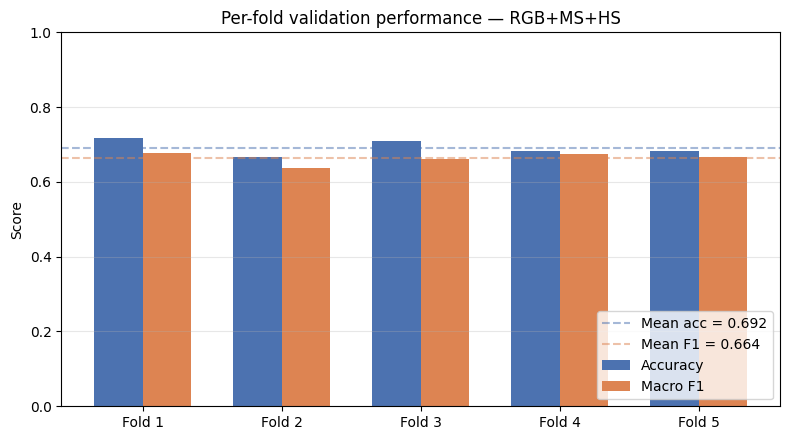

Saved: /kaggle/working/figures/fig4_per_fold_results.png


In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(N_FOLDS)
w = 0.35
ax.bar(x - w/2, results_df['val_acc'], w, label='Accuracy', color='#4c72b0')
ax.bar(x + w/2, results_df['val_f1'],  w, label='Macro F1', color='#dd8452')
ax.axhline(results_df.val_acc.mean(), color='#4c72b0', ls='--', alpha=0.5,
           label=f'Mean acc = {results_df.val_acc.mean():.3f}')
ax.axhline(results_df.val_f1.mean(), color='#dd8452', ls='--', alpha=0.5,
           label=f'Mean F1 = {results_df.val_f1.mean():.3f}')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in x])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Per-fold validation performance — RGB+MS+HS')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_fold_results.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig4_per_fold_results.png')

## 15. Final Summary Printout

Run this last cell to get a clean text summary of all results — useful for copying into the report or for verification.

In [22]:
print('='*60)
print('FINAL RESULTS — Tri-Modal Model (RGB + MS + HS)')
print('='*60)
print()
print('Method:     ResNet50 (ImageNet-pretrained) with learned 1D HS spectral encoder')
print('            24-channel input (3 RGB + 5 MS + 16 HS-encoded)')
print(f'Training:   {EPOCHS} epochs, AdamW (lr={LR}, wd={WEIGHT_DECAY}), Cosine LR')
print('Inputs:     RGB at 224x224 (ImageNet norm); MS upsampled to 224x224 (z-score);')
print('            HS at native 32x32 (z-score), upsampled to 224x224 after spectral encoder')
print('Train aug:  flips + 90° rotations (all modalities) + light color jitter (RGB only)')
print('Test:       no augmentation; 5-fold soft-vote ensemble for Kaggle submission')
print()
print('Per-fold validation metrics:')
print(results_df.to_string(index=False))
print()
print(f'Cross-validation mean:')
print(f'  Accuracy:  {results_df.val_acc.mean():.4f} ± {results_df.val_acc.std():.4f}')
print(f'  Macro F1:  {results_df.val_f1.mean():.4f} ± {results_df.val_f1.std():.4f}')
print()
print('Out-of-fold per-class metrics:')
print(classification_report(all_fold_targets, all_fold_preds, target_names=CLASS_NAMES, digits=3))
print()
print('Files saved to /kaggle/working/:')
for f in sorted(OUTPUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  figures/{f.name}')

FINAL RESULTS — Tri-Modal Model (RGB + MS + HS)

Method:     ResNet50 (ImageNet-pretrained) with learned 1D HS spectral encoder
            24-channel input (3 RGB + 5 MS + 16 HS-encoded)
Training:   25 epochs, AdamW (lr=0.0001, wd=0.0001), Cosine LR
Inputs:     RGB at 224x224 (ImageNet norm); MS upsampled to 224x224 (z-score);
            HS at native 32x32 (z-score), upsampled to 224x224 after spectral encoder
Train aug:  flips + 90° rotations (all modalities) + light color jitter (RGB only)
Test:       no augmentation; 5-fold soft-vote ensemble for Kaggle submission

Per-fold validation metrics:
 fold  best_epoch  val_acc   val_f1
    1          24 0.716667 0.678313
    2          23 0.666667 0.637597
    3          13 0.708333 0.662131
    4          14 0.683333 0.674237
    5          13 0.683333 0.667171

Cross-validation mean:
  Accuracy:  0.6917 ± 0.0204
  Macro F1:  0.6639 ± 0.0160

Out-of-fold per-class metrics:
              precision    recall  f1-score   support

      Hea

## What to do after this notebook finishes

1. **Download** from the Kaggle output panel:
   - `submission.csv` — submit this to the Kaggle Late Submission page
   - `cv_results.csv` — include in the report's results section
   - The 4 PNG figures in `figures/` — include in the report and slides

2. **Submit `submission.csv`** to the Kaggle competition page and note the public/private scores.

3. **Reference the report** (`Wheat_Disease_Report.docx`) and slides (`Wheat_Disease_Slides.pptx`) for the full three-way ablation comparison (RGB-only, RGB+MS, RGB+MS+HS) and accompanying analysis.